# The goal of this notebook is to analyze trends through the lens of outbreak-cyclones, and outbreak cores

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
import xarray as xr
from matplotlib.ticker import MaxNLocator

## Frequency of outbreak cyclones:

In [2]:
etc_summary = pd.read_csv('data/etc_summary_final.csv')

In [3]:
etc_summary

,track_id,track_start,track_end,time_min_msl,min_msl,n_steps,n_reports,n_tornado,n_hail,n_wind,n_cores_total,n_cores_kept,kept_reports,max_core_reports,time_max_reports
0,1.0,1995-12-01 00:00:00+00:00,1995-12-06 23:00:00+00:00,1995-12-02 22:00:00+00:00,980.3069,144,0,0,0,0,0,0,0,0,NaN
1,2.0,1995-12-01 00:00:00+00:00,1995-12-12 03:00:00+00:00,1995-12-10 06:00:00+00:00,961.9612,251,0,0,0,0,0,0,0,0,NaN
2,3.0,1995-12-03 06:00:00+00:00,1995-12-07 01:00:00+00:00,1995-12-05 04:00:00+00:00,994.3956,92,1,1,0,0,0,0,0,0,1995-12-06 04:00:00+00:00
3,4.0,1995-12-04 04:00:00+00:00,1995-12-06 04:00:00+00:00,1995-12-06 04:00:00+00:00,978.0338,49,0,0,0,0,0,0,0,0,NaN
4,5.0,1995-12-06 17:00:00+00:00,1995-12-08 01:00:00+00:00,1995-12-07 19:00:00+00:00,980.9462,31,0,0,0,0,0,0,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2220,6114.0,2025-03-24 18:00:00+00:00,2025-03-29 11:00:00+00:00,2025-03-27 22:00:00+00:00,1005.1210,106,5,0,4,1,1,0,0,0,2025-03-28 21:00:00+00:00
2221,6116.0,2025-03-26 17:00:00+00:00,2025-03-30 19:00:00+00:00,2025-03-29 10:00:00+00:00,982.2738,99,0,0,0,0,0,0,0,0,NaN
2222,6117.0,2025-03-26 22:00:00+00:00,2025-03-31 23:00:00+00:00,2025-03-31 20:00:00+00:00,992.6212,114,927,66,277,584,7,2,891,821,2025-03-30 20:00:00+00:00
2223,6119.0,2025-03-28 20:00:00+00:00,2025-03-31 21:00:00+00:00,2025-03-30 23:00:00+00:00,989.9344,73,1,0,1,0,0,0,0,0,2025-03-31 21:00:00+00:00


In [4]:
## Season aggregation
t = pd.to_datetime(etc_summary['track_start'], utc=True)
etc_summary['season'] = t.dt.year + (t.dt.month == 12).astype(int) #DJFM, labeled by ending year
etc_summary['is_outbreak'] = etc_summary['n_cores_kept'] > 0

seasonal = (etc_summary
            .groupby('season')
            .agg(n_total=('track_id','size'),
                 n_outbreak=('is_outbreak','sum')))
seasonal['frac_outbreak'] = seasonal['n_outbreak'] / seasonal['n_total']

In [5]:
seasonal

,n_total,n_outbreak,frac_outbreak
season,,,
1996,65,8,0.123077
1997,85,14,0.164706
1998,66,12,0.181818
1999,74,11,0.148649
2000,78,10,0.128205
2001,80,7,0.087500
2002,75,6,0.080000
2003,69,6,0.086957
2004,82,3,0.036585


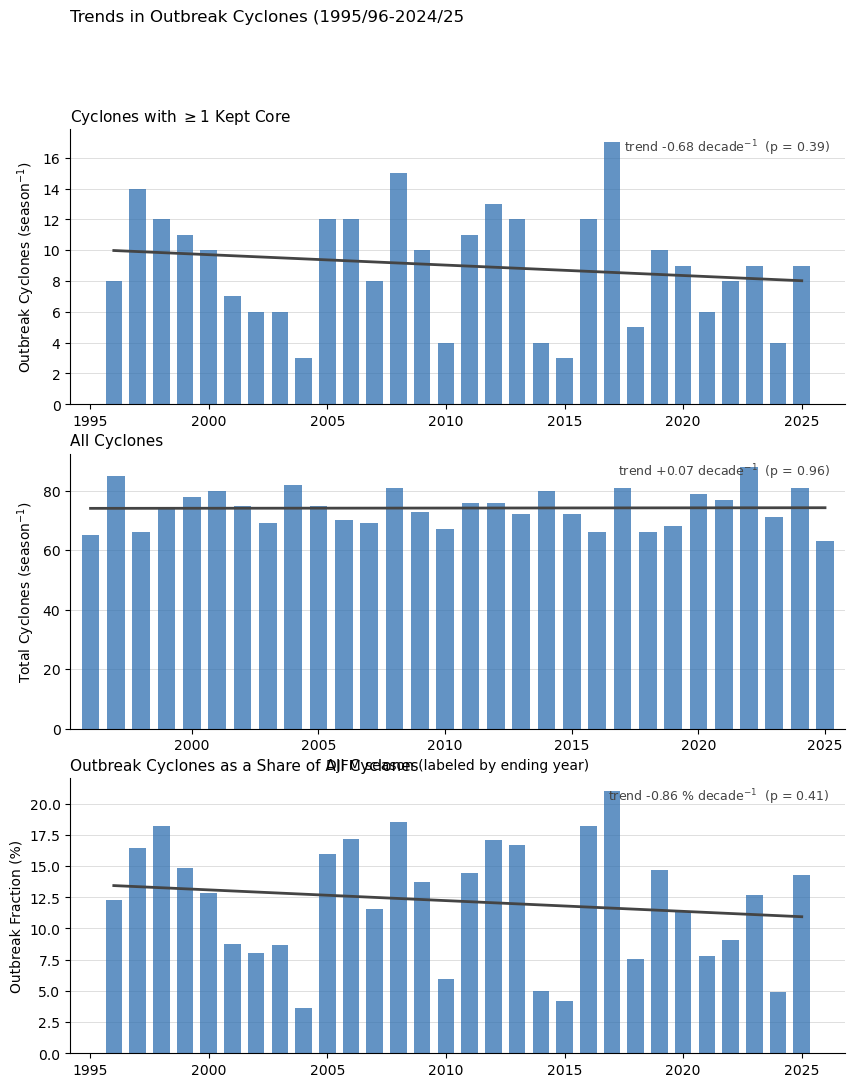

In [7]:
BLUE, INK = '#2f6fb0', '#444444'

x = seasonal.index.values.astype(float)

fig, axes = plt.subplots(3,1, figsize=(10,12), sharey=False,
                         gridspec_kw={'hspace': 0.18})

panels = [
    (axes[0], seasonal['n_outbreak'].values, 'Outbreak Cyclones (season$^{-1}$)',
     'Cyclones with $\\geq$1 Kept Core', '{:+.2f} decade$^{{-1}}$'),
     (axes[1], seasonal['n_total'].values, 'Total Cyclones (season$^{-1}$)',
                'All Cyclones', '{:+.2f} decade$^{{-1}}$'),
     (axes[2], seasonal['frac_outbreak'].values * 100, 'Outbreak Fraction (%)',
      'Outbreak Cyclones as a Share of All Cyclones', '{:+.2f} % decade$^{{-1}}$'),
      
]

for ax, y, ylabel, title, fmt in panels:
    reg = stats.linregress(x,y)
    ax.bar(x, y, width=0.7, color=BLUE, alpha=0.75, zorder=2)
    ax.plot(x, reg.intercept + reg.slope * x, color=INK, lw=2, zorder=3)
    ax.set_ylabel(ylabel)
    ax.set_title(title, loc='left', fontsize=11)
    ax.annotate(f"trend {fmt.format(reg.slope * 10)}  (p = {reg.pvalue:.2f})",
                xy=(0.98, 0.92), xycoords='axes fraction', ha='right',
                fontsize=9, color=INK)
    ax.grid(axis='y', color='0.85', lw=0.6, zorder=0)
    ax.set_axisbelow(True)

    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)

axes[1].set_xlabel('DJFM season (labeled by ending year)')
axes[1].set_xlim(x.min() - 0.8, x.max() + 0.8)
fig.suptitle('Trends in Outbreak Cyclones (1995/96-2024/25', x=0.125, ha='left')
plt.show()

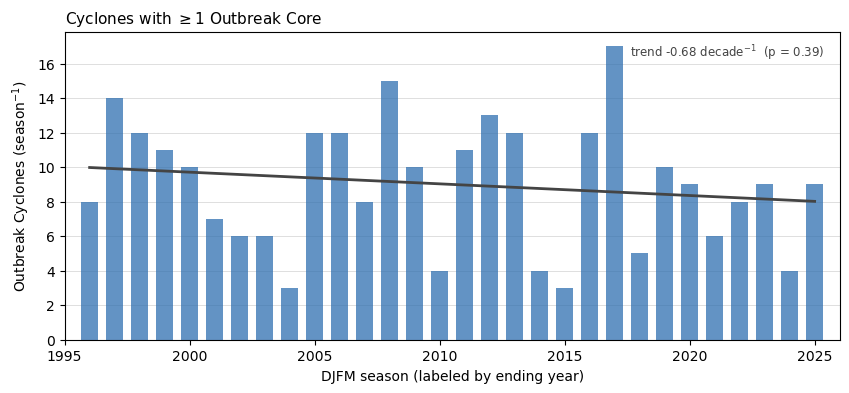

In [27]:
BLUE, INK = '#2f6fb0', '#444444'

x = seasonal.index.values.astype(float)
y = seasonal['n_outbreak'].values
ylabel = 'Outbreak Cyclones (season$^{-1}$)'
fmt = '{:+.2f} decade$^{{-1}}$'
title = 'Cyclones with $\\geq$1 Outbreak Core'

fig, ax = plt.subplots(figsize=(10,4))

reg = stats.linregress(x,y)
ax.bar(x, y, width=0.7, color=BLUE, alpha=0.75, zorder=2)
ax.plot(x, reg.intercept + reg.slope * x, color=INK, lw=2, zorder=3)
ax.set_ylabel(ylabel)
ax.set_title(title, loc='left', fontsize=11)
ax.annotate(f"trend {fmt.format(reg.slope * 10)}  (p = {reg.pvalue:.2f})",
            xy=(0.98, 0.92), xycoords='axes fraction', ha='right',
            fontsize=8.5, color=INK)
ax.grid(axis='y', color='0.85', lw=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xlabel('DJFM season (labeled by ending year)')
ax.set_xlim(x.min() - 1, x.max() + 1)
ax.set_xticks(range(1995,2026,5));

Ok so the frequency trend of of outbreak cyclones between 1995-2025 is not statististically significant. Perhaps if we look for before the last 30 years that could be different though...

## Decadal Composites (time of max reports):

### 3 Periods: 1996-2005, 2006-2015, 2016-2025

### Composites are of Outbreak Cyclones (at the time of max reports):

In [7]:
DECADE_DIR = Path("/data1/lepique/composites_decadal")

#### MSL:

In [8]:
oc_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_msl.nc", decode_times=False)
oc_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_msl.nc", decode_times=False)
oc_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_msl.nc", decode_times=False)

In [9]:
oc_2016_2025

<xarray.Dataset> Size: 2MB
Dimensions:      (snapshot: 89, y: 80, x: 80)
Coordinates:
  * y            (y) float64 640B -39.5 -38.5 -37.5 -36.5 ... 37.5 38.5 39.5
  * x            (x) float64 640B -39.5 -38.5 -37.5 -36.5 ... 37.5 38.5 39.5
Dimensions without coordinates: snapshot
Data variables:
    snap_pathid  (snapshot) int32 356B ...
    snap_lon     (snapshot) float64 712B ...
    snap_lat     (snapshot) float64 712B ...
    snap_time    (snapshot) int64 712B ...
    snap_msl     (snapshot, y, x) float32 2MB ...
    msl          (y, x) float32 26kB ...

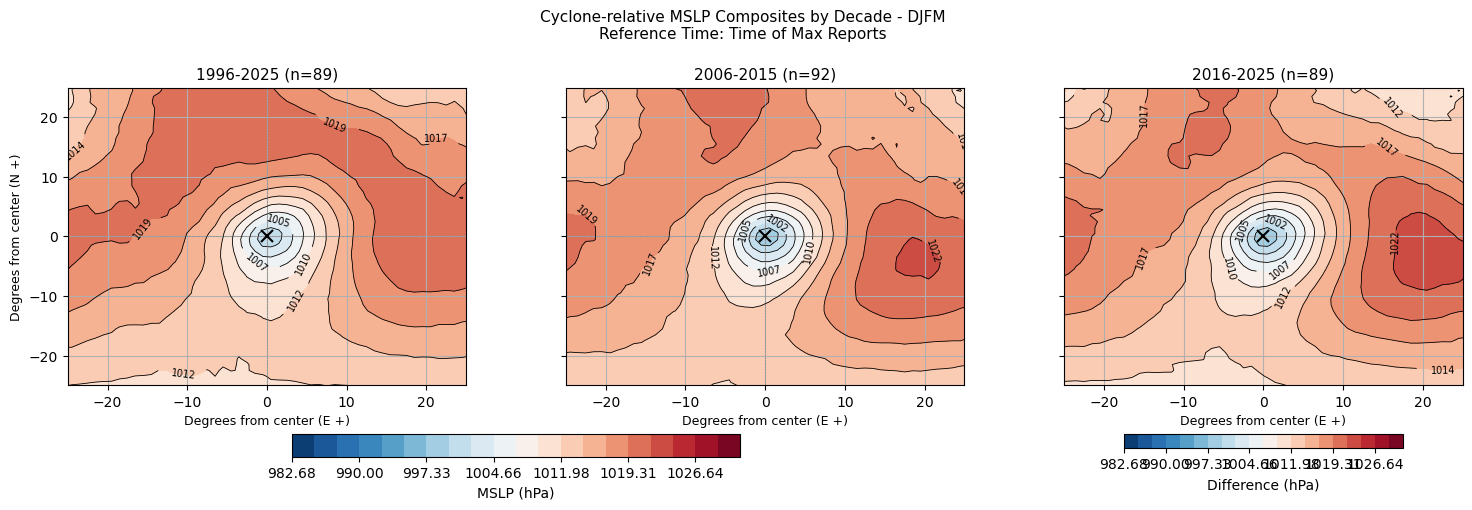

In [10]:
msl_1996_2005  = oc_1996_2005["msl"]  / 100  
msl_2005_2015  = oc_2006_2015["msl"]  / 100  
msl_2016_2025  = oc_2016_2025["msl"]  / 100  

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(msl_1996_2005.values), np.nanmin(msl_2005_2015.values), np.nanmin(msl_2016_2025))
vmax = max(np.nanmax(msl_1996_2005.values), np.nanmax(msl_2005_2015.values), np.nanmax(msl_2016_2025))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        msl_1996_2005["x"], msl_1996_2005["y"], msl_1996_2005,
        levels=levels, cmap="RdBu_r",
    )
cs1 = axes[0].contour(
        msl_1996_2005["x"], msl_1996_2005["y"], msl_1996_2005,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        msl_2005_2015["x"], msl_2005_2015["y"], msl_2005_2015,
        levels=levels, cmap="RdBu_r",
    )
cs2 = axes[1].contour(
        msl_2005_2015["x"], msl_2005_2015["y"], msl_2005_2015,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)


cf3 = axes[2].contourf(
        msl_2016_2025["x"], msl_2016_2025["y"], msl_2016_2025,
        levels=levels, cmap="RdBu_r",
    )
cs3 = axes[2].contour(
        msl_2016_2025["x"], msl_2016_2025["y"], msl_2016_2025,
        levels=levels, colors="k", linewidths=0.6,
    )


#axes[2].axhline(0, color="gray", linewidth=0.4, linestyle="--")
#axes[2].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[:2], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("MSLP (hPa)", fontsize=10)

cbar2 = fig.colorbar(cf3, ax=axes[2], orientation="horizontal", pad=0.12, shrink=0.7)
cbar2.set_label("Difference (hPa)", fontsize=10)

fig.suptitle("Cyclone-relative MSLP Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### 2m Temperature:

In [11]:
oc_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_t2m.nc", decode_times=False)
oc_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_t2m.nc", decode_times=False)
oc_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_t2m.nc", decode_times=False)

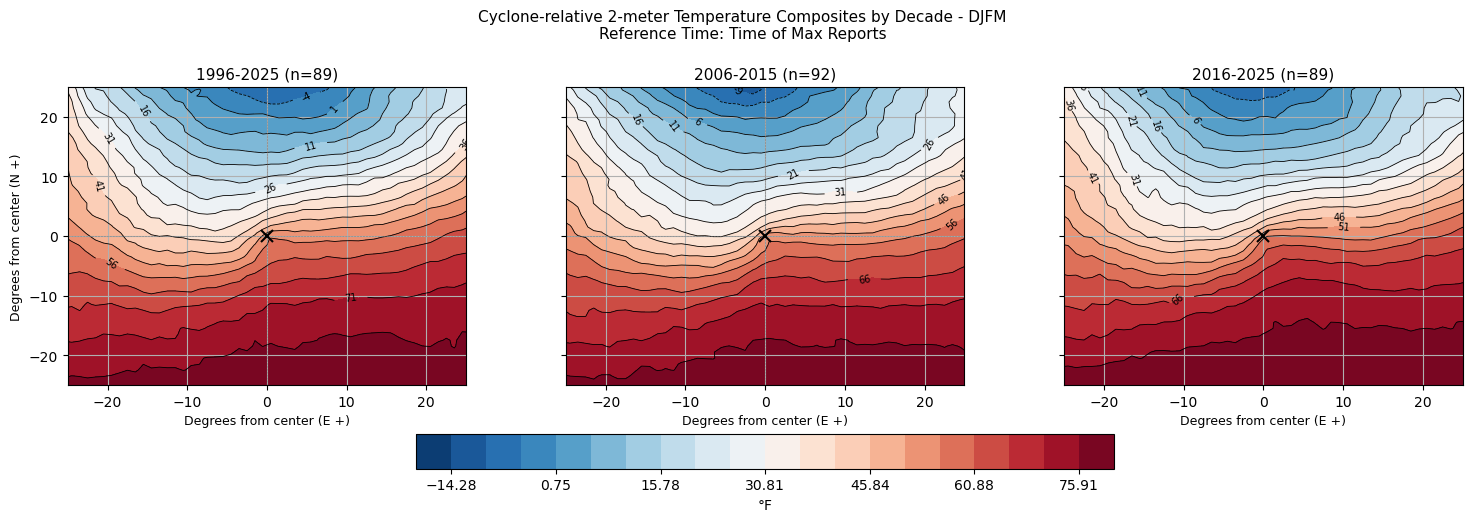

In [12]:
t2m_1996_2005  = (oc_1996_2005["t2m"] - 273.15) * 9/5 + 32
t2m_2005_2015  = (oc_2006_2015["t2m"] - 273.15) * 9/5 + 32   
t2m_2016_2025  = (oc_2016_2025["t2m"] - 273.15) * 9/5 + 32   

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(t2m_1996_2005.values), np.nanmin(t2m_2005_2015.values), np.nanmin(t2m_2016_2025))
vmax = max(np.nanmax(t2m_1996_2005.values), np.nanmax(t2m_2005_2015.values), np.nanmax(t2m_2016_2025))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        t2m_1996_2005["x"], t2m_1996_2005["y"], t2m_1996_2005,
        levels=levels, cmap="RdBu_r",
    )
cs1 = axes[0].contour(
        t2m_1996_2005["x"], t2m_1996_2005["y"], t2m_1996_2005,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        t2m_2005_2015["x"], t2m_2005_2015["y"], t2m_2005_2015,
        levels=levels, cmap="RdBu_r",
    )
cs2 = axes[1].contour(
        t2m_2005_2015["x"], t2m_2005_2015["y"], t2m_2005_2015,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)


cf3 = axes[2].contourf(
        t2m_2016_2025["x"], t2m_2016_2025["y"], t2m_2016_2025,
        levels=levels, cmap="RdBu_r",
    )
cs3 = axes[2].contour(
        t2m_2016_2025["x"], t2m_2016_2025["y"], t2m_2016_2025,
        levels=levels, colors="k", linewidths=0.6,
    )


#axes[2].axhline(0, color="gray", linewidth=0.4, linestyle="--")
#axes[2].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("°F", fontsize=10)

fig.suptitle("Cyclone-relative 2-meter Temperature Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### 2m Dewpoint:

In [13]:
oc_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_d2m.nc", decode_times=False)
oc_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_d2m.nc", decode_times=False)
oc_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_d2m.nc", decode_times=False)

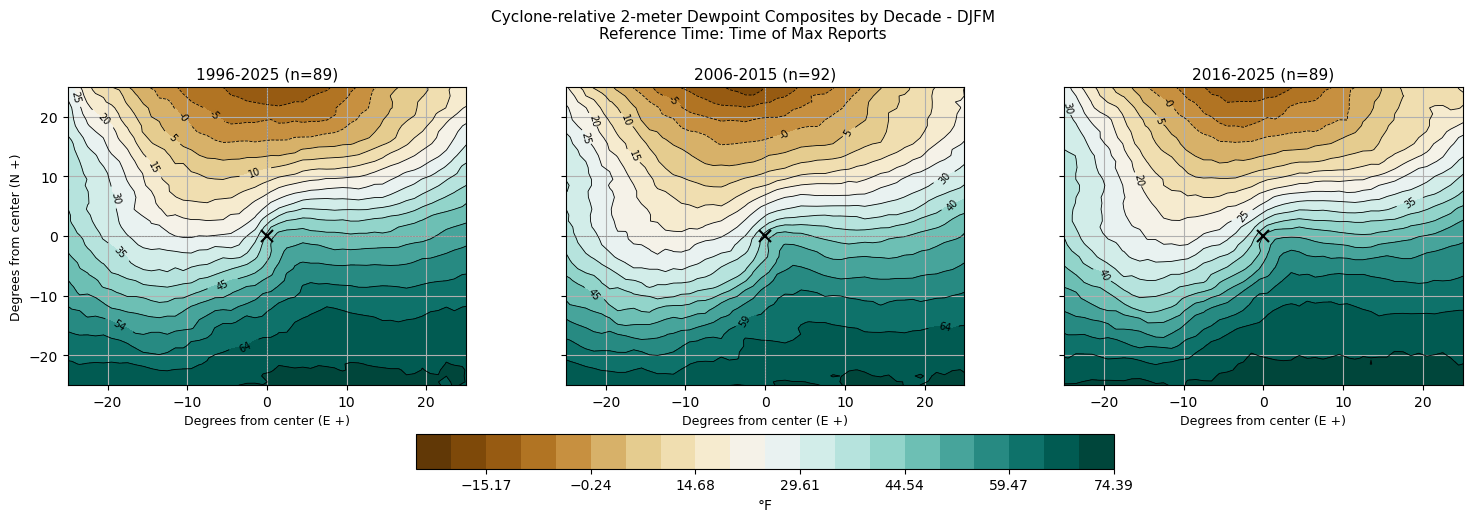

In [14]:
d2m_1996_2005  = (oc_1996_2005["d2m"] - 273.15) * 9/5 + 32
d2m_2005_2015  = (oc_2006_2015["d2m"] - 273.15) * 9/5 + 32
d2m_2016_2025  = (oc_2016_2025["d2m"] - 273.15) * 9/5 + 32

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(d2m_1996_2005.values), np.nanmin(d2m_2005_2015.values), np.nanmin(d2m_2016_2025))
vmax = max(np.nanmax(d2m_1996_2005.values), np.nanmax(d2m_2005_2015.values), np.nanmax(d2m_2016_2025))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        d2m_1996_2005["x"], d2m_1996_2005["y"], d2m_1996_2005,
        levels=levels, cmap="BrBG",
    )
cs1 = axes[0].contour(
        d2m_1996_2005["x"], d2m_1996_2005["y"], d2m_1996_2005,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        d2m_2005_2015["x"], d2m_2005_2015["y"], d2m_2005_2015,
        levels=levels, cmap="BrBG",
    )
cs2 = axes[1].contour(
        d2m_2005_2015["x"], d2m_2005_2015["y"], d2m_2005_2015,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)


cf3 = axes[2].contourf(
        d2m_2016_2025["x"], d2m_2016_2025["y"], d2m_2016_2025,
        levels=levels, cmap="BrBG",
    )
cs3 = axes[2].contour(
        d2m_2016_2025["x"], d2m_2016_2025["y"], d2m_2016_2025,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("°F", fontsize=10)

fig.suptitle("Cyclone-relative 2-meter Dewpoint Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### Total Column Integrated Water Vapor:

In [15]:
oc_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_tcwv.nc", decode_times=False)
oc_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_tcwv.nc", decode_times=False)
oc_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_tcwv.nc", decode_times=False)

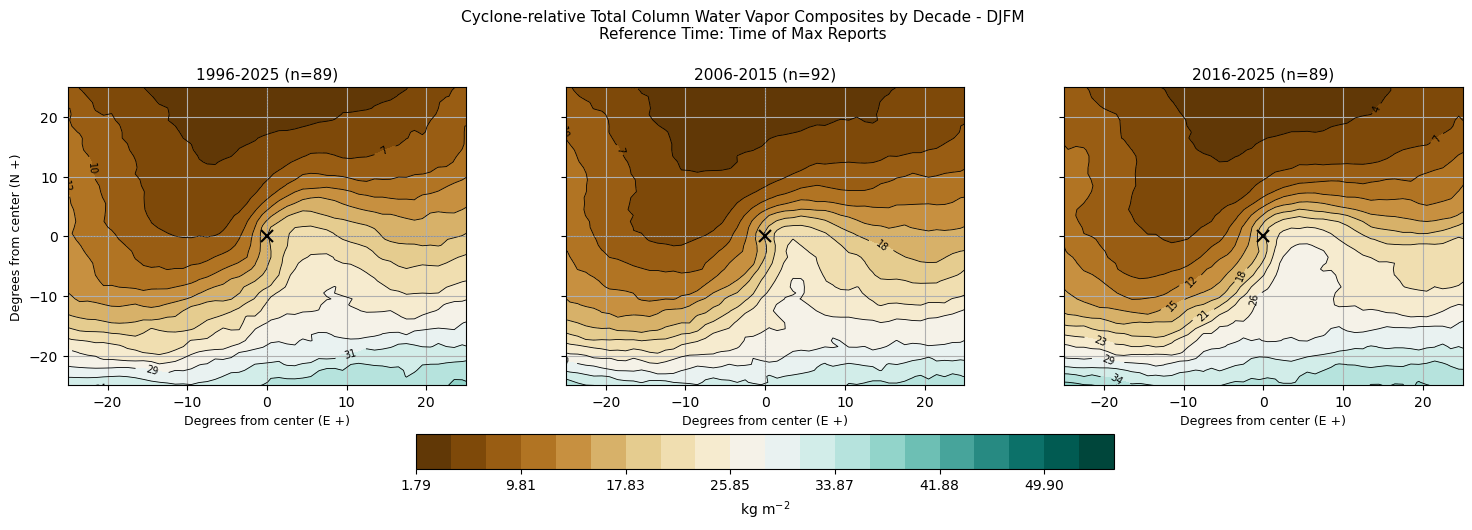

In [16]:
tcwv_1996_2005  = oc_1996_2005["tcwv"]
tcwv_2005_2015  = oc_2006_2015["tcwv"]
tcwv_2016_2025  = oc_2016_2025["tcwv"]

# Shared contour levels across both panels for direct comparability
vmin = min(np.nanmin(tcwv_1996_2005.values), np.nanmin(tcwv_2005_2015.values), np.nanmin(tcwv_2016_2025))
vmax = max(np.nanmax(tcwv_1996_2005.values), np.nanmax(tcwv_2005_2015.values), np.nanmax(tcwv_2016_2025))
levels = np.linspace(vmin, vmax, 21)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        tcwv_1996_2005["x"], tcwv_1996_2005["y"], tcwv_1996_2005,
        levels=levels, cmap="BrBG",
    )
cs1 = axes[0].contour(
        tcwv_1996_2005["x"], tcwv_1996_2005["y"], tcwv_1996_2005,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        tcwv_2005_2015["x"], tcwv_2005_2015["y"], tcwv_2005_2015,
        levels=levels, cmap="BrBG",
    )
cs2 = axes[1].contour(
        tcwv_2005_2015["x"], tcwv_2005_2015["y"], tcwv_2005_2015,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].axhline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].axvline(0, color="gray", linewidth=0.4, linestyle="--")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)


cf3 = axes[2].contourf(
        tcwv_2016_2025["x"], tcwv_2016_2025["y"], tcwv_2016_2025,
        levels=levels, cmap="BrBG",
    )
cs3 = axes[2].contour(
        tcwv_2016_2025["x"], tcwv_2016_2025["y"], tcwv_2016_2025,
        levels=levels, colors="k", linewidths=0.6,
    )

axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("kg m$^{-2}$", fontsize=10)

fig.suptitle("Cyclone-relative Total Column Water Vapor Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### 850 hPa Winds:

In [17]:
u_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_u850.nc", decode_times=False)["u(5)"]
v_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_v850.nc", decode_times=False)["v(5)"]

u_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_u850.nc", decode_times=False)["u(5)"]
v_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_v850.nc", decode_times=False)["v(5)"]

u_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_u850.nc", decode_times=False)["u(5)"]
v_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_v850.nc", decode_times=False)["v(5)"]

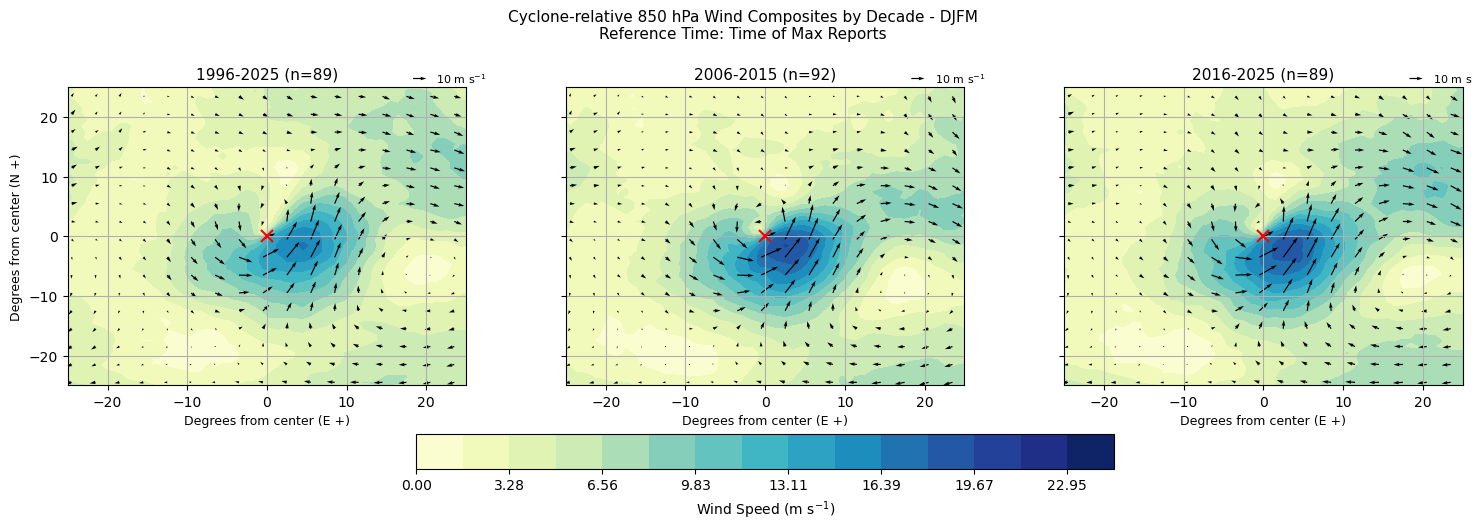

In [18]:
spd_1996_2005  = np.sqrt(u_1996_2005**2  + v_1996_2005**2)
spd_2006_2015  = np.sqrt(u_2006_2015**2  + v_2006_2015**2)
spd_2016_2025  = np.sqrt(u_2016_2025**2  + v_2016_2025**2)

# Shared contour levels across both panels for direct comparability
vmax = max(np.nanmax(spd_1996_2005.values), np.nanmax(spd_2006_2015.values), np.nanmax(spd_2016_2025.values))
levels = np.linspace(0, vmax, 16)

skip = 3

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        u_1996_2005["x"], u_1996_2005["y"], spd_1996_2005,
        levels=levels, cmap="YlGnBu",
    )
q1 = axes[0].quiver(
        u_1996_2005["x"][::skip], u_1996_2005["y"][::skip],
        u_1996_2005[::skip, ::skip], v_1996_2005[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )
axes[0].quiverkey(q1, 0.9, 1.03, 10, "10 m s$^{-1}$", labelpos="E", fontproperties={"size": 8})
axes[0].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        u_2006_2015["x"], u_2006_2015["y"], spd_2006_2015,
        levels=levels, cmap="YlGnBu",
    )
q2 = axes[1].quiver(
        u_2006_2015["x"][::skip], u_2006_2015["y"][::skip],
        u_2006_2015[::skip, ::skip], v_2006_2015[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )
axes[1].quiverkey(q2, 0.9, 1.03, 10, "10 m s$^{-1}$", labelpos="E", fontproperties={"size": 8})
axes[1].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)

cf3 = axes[2].contourf(
        u_2016_2025["x"], u_2016_2025["y"], spd_2016_2025,
        levels=levels, cmap="YlGnBu",
    )
q3 = axes[2].quiver(
        u_2016_2025["x"][::skip], u_2016_2025["y"][::skip],
        u_2016_2025[::skip, ::skip], v_2016_2025[::skip, ::skip],
        scale=300, width=0.003, color="black",
    )
axes[2].quiverkey(q3, 0.9, 1.03, 10, "10 m s$^{-1}$", labelpos="E", fontproperties={"size": 8})
axes[2].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("Wind Speed (m s$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative 850 hPa Wind Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### 500 hPa Heights and Vorticity:

In [19]:
z_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_z500.nc", decode_times=False)["z(12)"] / 9.80665
vo_1996_2005 = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_vo500.nc", decode_times=False)["vo(12)"] * 1e5

z_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_z500.nc", decode_times=False)["z(12)"] / 9.80665
vo_2006_2015 = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_vo500.nc", decode_times=False)["vo(12)"] * 1e5

z_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_z500.nc", decode_times=False)["z(12)"] / 9.80665
vo_2016_2025 = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_vo500.nc", decode_times=False)["vo(12)"] * 1e5

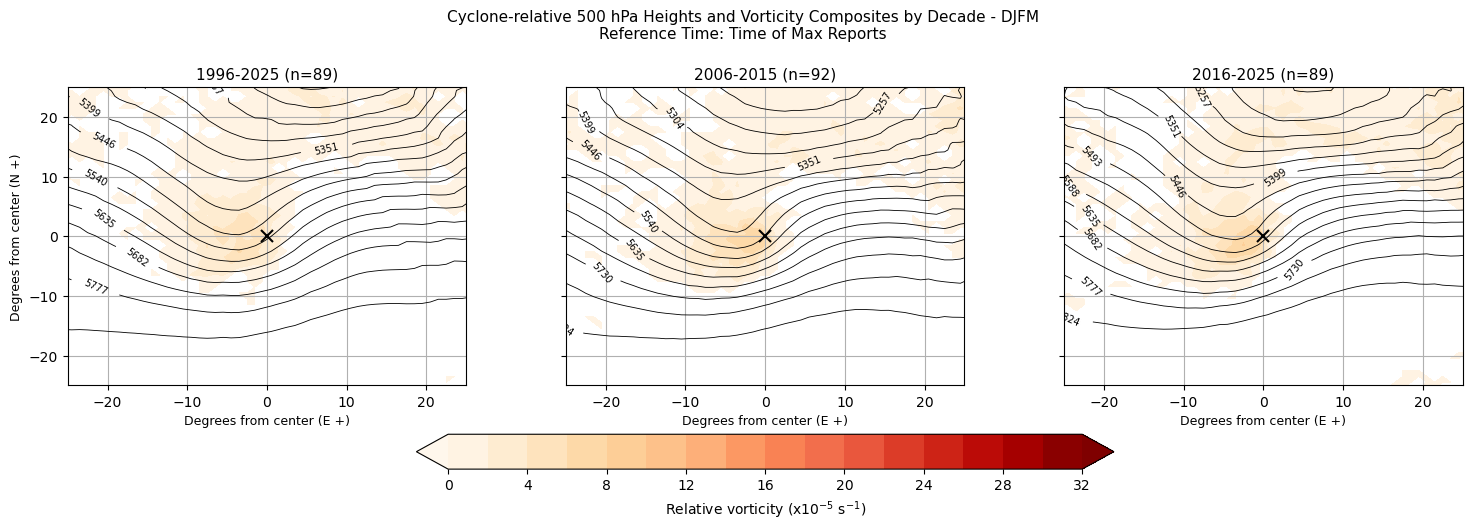

In [20]:
# Shared contour/shading levels across both panels for direct comparability
h_vmin = min(np.nanmin(z_1996_2005.values), np.nanmin(z_2006_2015.values), np.nanmin(z_2016_2025.values))
h_vmax = max(np.nanmax(z_1996_2005.values), np.nanmax(z_2006_2015.values), np.nanmax(z_2016_2025.values))
h_levels = np.linspace(h_vmin, h_vmax, 21)

pos_vort_1996_2005 = np.where(vo_1996_2005.values > 0, vo_1996_2005.values, np.nan)
pos_vort_2006_2015 = np.where(vo_2006_2015.values > 0, vo_2006_2015.values, np.nan)
pos_vort_2016_2025 = np.where(vo_2016_2025.values > 0, vo_2016_2025.values, np.nan)

vort_vmax = max(np.nanmax(pos_vort_1996_2005), np.nanmax(pos_vort_2006_2015), np.nanmax(pos_vort_2016_2025))
vort_levels = np.arange(0, vort_vmax + 2, 2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        vo_1996_2005["x"], vo_1996_2005["y"], pos_vort_1996_2005,
        levels=vort_levels, cmap="OrRd", extend="both",
    )
cs1 = axes[0].contour(
        z_1996_2005["x"], z_1996_2005["y"], z_1996_2005.values,
        levels=h_levels, colors="k", linewidths=0.6,
    )
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        vo_2006_2015["x"], vo_2006_2015["y"], pos_vort_2006_2015,
        levels=vort_levels, cmap="OrRd", extend="both",
    )
cs2 = axes[1].contour(
        z_2006_2015["x"], z_2006_2015["y"], z_2006_2015.values,
        levels=h_levels, colors="k", linewidths=0.6,
    )
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)

cf3 = axes[2].contourf(
        vo_2016_2025["x"], vo_2016_2025["y"], pos_vort_2016_2025,
        levels=vort_levels, cmap="OrRd", extend="both",
    )
cs3 = axes[2].contour(
        z_2016_2025["x"], z_2016_2025["y"], z_2016_2025.values,
        levels=h_levels, colors="k", linewidths=0.6,
    )
axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("Relative vorticity (x10$^{-5}$ s$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative 500 hPa Heights and Vorticity Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### 250 hPa Heights and Winds:

In [11]:
u_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_u250.nc", decode_times=False)["u(17)"]
v_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_v250.nc", decode_times=False)["v(17)"]
z_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_z250.nc", decode_times=False)["z(17)"] / 9.80665

u_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_u250.nc", decode_times=False)["u(17)"]
v_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_v250.nc", decode_times=False)["v(17)"]
z_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_z250.nc", decode_times=False)["z(17)"] / 9.80665

u_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_u250.nc", decode_times=False)["u(17)"]
v_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_v250.nc", decode_times=False)["v(17)"]
z_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_z250.nc", decode_times=False)["z(17)"] / 9.80665

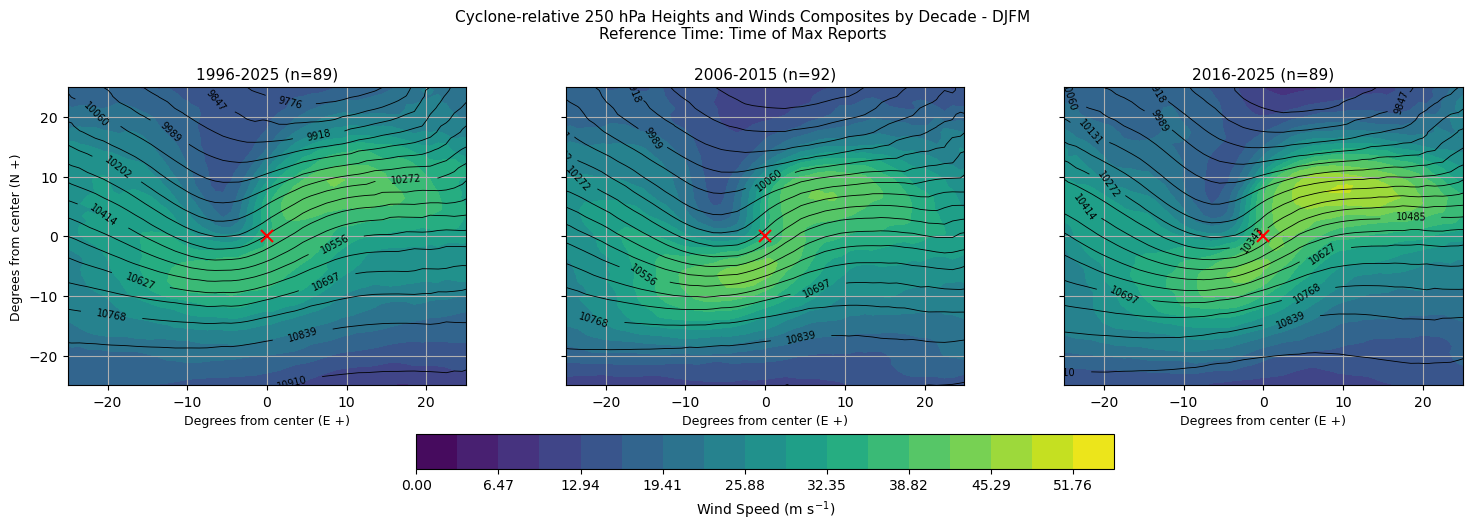

In [21]:
spd_1996_2005  = np.sqrt(u_1996_2005**2  + v_1996_2005**2)
spd_2006_2015  = np.sqrt(u_2006_2015**2  + v_2006_2015**2)
spd_2016_2025  = np.sqrt(u_2016_2025**2  + v_2016_2025**2)

# Shared contour/shading levels across both panels for direct comparability
z_vmin = min(np.nanmin(z_1996_2005.values), np.nanmin(z_2006_2015.values), np.nanmin(z_2016_2025.values))
z_vmax = max(np.nanmax(z_1996_2005.values), np.nanmax(z_2006_2015.values), np.nanmax(z_2016_2025.values))
z_levels = np.linspace(z_vmin, z_vmax, 21)

vmax = max(np.nanmax(spd_1996_2005.values), np.nanmax(spd_2006_2015.values), np.nanmax(spd_2016_2025.values))
levels = np.linspace(0, 55, 18)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        u_1996_2005["x"], u_1996_2005["y"], spd_1996_2005,
        levels=levels, cmap="viridis",
    )
cs1 = axes[0].contour(
        z_1996_2005["x"], z_1996_2005["y"], z_1996_2005,
        levels=z_levels, colors="k", linewidths=0.6,
    )
axes[0].clabel(cs1, inline=True, fontsize=7, fmt="%.0f")
axes[0].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2025 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        u_2006_2015["x"], u_2006_2015["y"], spd_2006_2015,
        levels=levels, cmap="viridis",
    )
cs2 = axes[1].contour(
        z_2006_2015["x"], z_2006_2015["y"], z_2006_2015,
        levels=z_levels, colors="k", linewidths=0.6,
    )
axes[1].clabel(cs2, inline=True, fontsize=7, fmt="%.0f")
axes[1].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[1].set_xlim(-25, 25)
axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)

cf3 = axes[2].contourf(
        u_2016_2025["x"], u_2016_2025["y"], spd_2016_2025,
        levels=levels, cmap="viridis",
    )
cs3 = axes[2].contour(
        z_2016_2025["x"], z_2016_2025["y"], z_2016_2025,
        levels=z_levels, colors="k", linewidths=0.6,
    )
axes[2].clabel(cs3, inline=True, fontsize=7, fmt="%.0f")
axes[2].plot(0, 0, "rx", markersize=8, markeredgewidth=1.5)
axes[2].set_xlim(-25, 25)
axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("Wind Speed (m s$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative 250 hPa Heights and Winds Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()

#### CAPE:

In [34]:
cape_1996_2005  = xr.open_dataset(DECADE_DIR / "oc_1996-2005_time_maxreports_cape.nc", decode_times=False)["cape"]
cape_2006_2015  = xr.open_dataset(DECADE_DIR / "oc_2006-2015_time_maxreports_cape.nc", decode_times=False)["cape"]
cape_2016_2025  = xr.open_dataset(DECADE_DIR / "oc_2016-2025_time_maxreports_cape.nc", decode_times=False)["cape"]

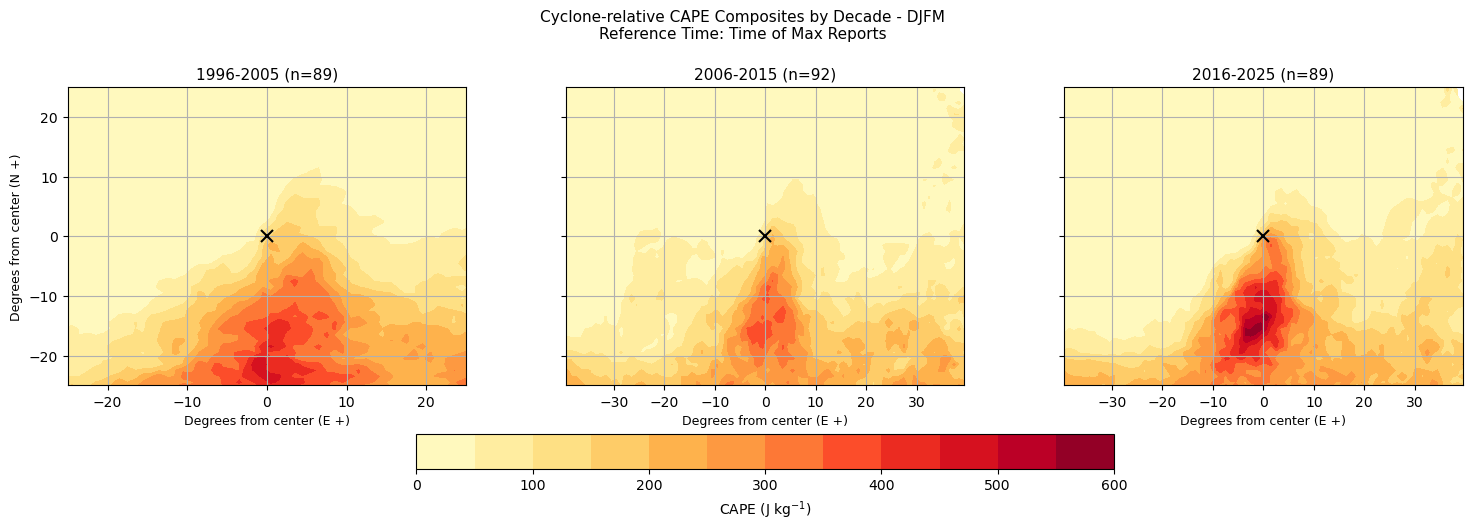

In [37]:
# Shared contour levels across both panels for direct comparability
levels = np.arange(0, 600 + 50, 50)

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

cf1 = axes[0].contourf(
        cape_1996_2005["x"], cape_1996_2005["y"], cape_1996_2005,
        levels=levels, cmap="YlOrRd",
    )
axes[0].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
axes[0].set_xlim(-25, 25)
axes[0].set_ylim(-25, 25)
axes[0].set_title("1996-2005 (n=89)", fontsize=11)
axes[0].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[0].grid(True)

cf2 = axes[1].contourf(
        cape_2006_2015["x"], cape_2006_2015["y"], cape_2006_2015,
        levels=levels, cmap="YlOrRd",
    )
axes[1].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
#axes[1].set_xlim(-25, 25)
#axes[1].set_ylim(-25, 25)
axes[1].set_title("2006-2015 (n=92)", fontsize=11)
axes[1].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[1].grid(True)

cf3 = axes[2].contourf(
        cape_2016_2025["x"], cape_2016_2025["y"], cape_2016_2025,
        levels=levels, cmap="YlOrRd",
    )
axes[2].plot(0, 0, "kx", markersize=8, markeredgewidth=1.5)
#axes[2].set_xlim(-25, 25)
#axes[2].set_ylim(-25, 25)
axes[2].set_title("2016-2025 (n=89)", fontsize=11)
axes[2].set_xlabel("Degrees from center (E +)", fontsize=9)
axes[2].grid(True)

axes[0].set_ylabel("Degrees from center (N +)", fontsize=9)

fig.subplots_adjust(bottom=0.2, wspace=0.25)

cbar1 = fig.colorbar(cf1, ax=axes[::], orientation="horizontal", pad=0.12, shrink=0.5)
cbar1.set_label("CAPE (J kg$^{-1}$)", fontsize=10)

fig.suptitle("Cyclone-relative CAPE Composites by Decade - DJFM\nReference Time: Time of Max Reports",
             fontsize=11, y=1.01)

plt.show()